In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import variance, stddev, col, count, isnan, when
from pyspark.sql.types import NumericType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression as SKLogisticRegression
from sklearn.preprocessing import StandardScaler as SKStandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [2]:
fraud_channels =  ['API', 'ATM', 'BIO', 'BISP', 'Business App', 'Business App API', 'Cheetay', 'JC Keyboard', 'Merchant Payment', 'Mobile App', 'NEW_JC_APP', 'PAYPAK', 'PGW', 'Payment Gateway', 'QR Payment', 'Self Care App', 'THIRD_PARTY_WEB', 'USSD', 'USSD API', 'USSD_API', 'VRG']
fraud_types =  ['Online Payment', 'PTS ATM Withdrawal', 'PTS Purchase Payment', 'Transfer(C2C)', 'MFS Card Withdraw', 'Cash in', 'Cash out', 'IBFT Outgoing Customer', 'IBFT Outgoing OTC', 'Merchant Payment', 'Transfer(B2C)', 'Transfer(C2B)', 'Jazz Load (Prepaid top-up)', 'Business Cash Out', 'Customer Remit To CNIC', 'Donation', 'Get Loan', 'IBFT Credit', 'Others', 'Utility Bills Payment', 'Purchase Payment', 'Auto Debit', 'Indigo Bills (Postpaid payment)']

channels_in_clause = ", ".join([f"'{ch}'" for ch in fraud_channels])
types_in_clause = ", ".join([f"'{tp}'" for tp in fraud_types])

CLICKHOUSE_CONFIG = {
    'host': 'localhost',
    'port': 9000,
    'database': 'public',
    'user': 'default',
    'password': 'DfsTeChB1'
}

url = f"jdbc:ch://{CLICKHOUSE_CONFIG['host']}:8123/{CLICKHOUSE_CONFIG['database']}"
user = CLICKHOUSE_CONFIG['user'] 
password = CLICKHOUSE_CONFIG['password']
driver = "com.clickhouse.jdbc.ClickHouseDriver"

packages = [
    "com.clickhouse.spark:clickhouse-spark-runtime-3.5_2.12:0.8.1",
    "com.clickhouse:clickhouse-client:0.9.4",
    "com.clickhouse:clickhouse-http-client:0.9.4",
    "org.apache.httpcomponents.client5:httpclient5:5.2.1"
]

spark = (SparkSession.builder
    .appName("poc-model-training")
    # .master("spark://10.205.161.118:7077")
    .master("local[*]")
    .config("spark.jars.packages", ",".join(packages))
    .config("spark.executor.memory", "150g")
    .config("spark.executor.memoryOverhead", "5g")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.cores", "32")
    .config("spark.executor.instances", "2")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.default.parallelism", "96")
    .getOrCreate()
)
    
# Configure ClickHouse catalog
spark.conf.set("spark.sql.catalog.clickhouse", "com.clickhouse.spark.ClickHouseCatalog")
spark.conf.set("spark.sql.catalog.clickhouse.host", "localhost")
spark.conf.set("spark.sql.catalog.clickhouse.protocol", "http")
spark.conf.set("spark.sql.catalog.clickhouse.http_port", "8123")
spark.conf.set("spark.sql.catalog.clickhouse.user", "default")
spark.conf.set("spark.sql.catalog.clickhouse.password", "DfsTeChB1")
spark.conf.set("spark.sql.catalog.clickhouse.database", "public")
spark.conf.set("spark.clickhouse.write.format", "json")           

:: loading settings :: url = jar:file:/root/miniconda3/envs/fraud-spark/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
com.clickhouse.spark#clickhouse-spark-runtime-3.5_2.12 added as a dependency
com.clickhouse#clickhouse-client added as a dependency
com.clickhouse#clickhouse-http-client added as a dependency
org.apache.httpcomponents.client5#httpclient5 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-7891a1e5-2c14-45f6-a4dc-6681eb5b6ffa;1.0
	confs: [default]
	found com.clickhouse.spark#clickhouse-spark-runtime-3.5_2.12;0.8.1 in central
	found com.clickhouse#clickhouse-client;0.9.4 in central
	found com.clickhouse#clickhouse-data;0.9.4 in central
	found commons-codec#commons-codec;1.17.1 in central
	found commons-io#commons-io;2.16.1 in central
	found org.apache.commons#commons-lang3;3.18.0 in central
	found org.apache.commons#commons-compress;1.27.1 in central
	found com.clickhouse#clickhouse-http-client;0.9.4 in central
	found org.apache.httpcomponents.client5#http

# Data Extraction

In [3]:
TRAIN_START_DATE = '2025-06-01'
TRAIN_END_DATE = '2025-06-01'
TEST_START_DATE = '2025-07-01'
TEST_END_DATE = '2025-07-01'

In [4]:
selected_cols = [
    'trans_id',
'cutoff_date',
'fraud_flag',
 'trx_amt',
 'mbar_registered_channel',
 'hour_of_day',
 'day_of_week',
 'is_weekend',
 'is_night',
 'user_total_txns_3d',
 'user_total_amount_3d',
 'user_avg_amount_3d',
 'user_max_amount_3d',
 'user_min_amount_3d',
 'user_unique_recipients_3d',
 'user_unique_channels_3d',
 'user_unique_types_3d',
 'user_total_txns_7d',
 'user_total_amount_7d',
 'user_avg_amount_7d',
 'user_median_amount_7d',
 'user_max_amount_7d',
 'user_min_amount_7d',
 'user_unique_recipients_7d',
 'user_unique_channels_7d',
 'user_unique_types_7d',
 'user_most_used_channel_7d',
 'user_last_used_channel',
 'user_channel_diversity_score_7d',
 'user_most_used_type_7d',
 'user_last_used_type',
 'user_type_diversity_score_7d',
 'user_avg_amount_per_recipient_7d',
 'user_max_amount_to_single_recipient_7d',
 'user_recipient_concentration_ratio_7d',
 'user_avg_time_between_txns_7d',
 'user_txn_frequency_score_7d',
 'user_days_since_last_txn']

query_train = f"""
    SELECT {', '.join(selected_cols)}
    FROM clickhouse.public.stixor_fraud_features_distributed
    WHERE cutoff_date BETWEEN '{TRAIN_START_DATE}' AND '{TRAIN_END_DATE}'
    AND mbar_account_type_name = 'Customer Account'
                    AND trx_channel='NEW_JC_APP'
                    AND trx_type='Transfer(C2C)'
                    AND ac_to IS NOT NULL 
                    AND ac_to<>''
		    AND start_balance<>end_balance

"""

query_test = f"""
    SELECT {', '.join(selected_cols)}
    FROM clickhouse.public.stixor_fraud_features_distributed
    WHERE cutoff_date BETWEEN '{TEST_START_DATE}' AND '{TEST_END_DATE}'
    AND mbar_account_type_name = 'Customer Account'
                    AND trx_channel='NEW_JC_APP'
                    AND trx_type='Transfer(C2C)'
                    AND ac_to IS NOT NULL 
                    AND ac_to<>''
		    AND start_balance<>end_balance
"""

df_train_raw = spark.sql(query_train)
df_test_raw = spark.sql(query_test)

In [5]:
print(f"Train data: {df_train_raw.count():,} records ({TRAIN_START_DATE} to {TRAIN_END_DATE})")
print(f"Test data: {df_test_raw.count():,} records ({TEST_START_DATE} to {TEST_END_DATE})")

Train data: 1,389,285 records (2025-06-01 to 2025-06-01)


Test data: 1,429,882 records (2025-07-01 to 2025-07-01)


In [6]:
all_columns = df_train_raw.columns
features = [c for c in all_columns if c not in ['cutoff_date','fraud_flag']]
numerical_cols = [
 'start_balance',
 'trx_amt',
 'hour_of_day',
 'day_of_week',
 'is_weekend',
 'is_night',
 'is_business_hours',
 'is_unusual_hour',
 'night_weekend_combo',
 'start_balance_log',
 'txn_txns_3d',
 'txn_total_amount_3d',
 'txn_avg_amount_3d',
 'txn_max_amount_3d',
 'txn_min_amount_3d',
 'txn_unique_recipients_3d',
 'txn_unique_channels_3d',
 'txn_unique_types_3d',
 'txn_is_high_activity_3d',
 'txn_multi_channel_recent',
 'txn_amount_deviation_from_avg',
 'txn_night_txns_3d',
 'txn_weekend_txns_3d',
 'user_total_txns_3d',
 'user_total_amount_3d',
 'user_avg_amount_3d',
 'user_median_amount_3d',
 'user_max_amount_3d',
 'user_min_amount_3d',
 'user_unique_recipients_3d',
 'user_unique_channels_3d',
 'user_unique_types_3d',
 'user_total_txns_7d',
 'user_total_amount_7d',
 'user_avg_amount_7d',
 'user_median_amount_7d',
 'user_max_amount_7d',
 'user_min_amount_7d',
 'user_unique_recipients_7d',
 'user_unique_channels_7d',
 'user_unique_types_7d',
 'user_most_used_channel_7d',
 'user_last_used_channel',
 'user_channel_diversity_score_7d',
 'user_most_used_type_7d',
 'user_last_used_type',
 'user_type_diversity_score_7d',
 'user_night_txns_7d',
 'user_weekend_txns_7d',
 'user_peak_hour_txns_7d',
 'user_off_peak_hour_txns_7d',
 'user_avg_start_balance_7d',
 'user_avg_end_balance_7d',
 'user_min_balance_7d',
 'user_max_balance_7d',
 'user_balance_volatility_7d',
 'user_avg_amount_per_recipient_7d',
 'user_max_amount_to_single_recipient_7d',
 'user_recipient_concentration_ratio_7d',
 'user_avg_time_between_txns_7d',
 'user_txn_frequency_score_7d',
 'user_days_since_last_txn']
feature_name_mapping = {
    'trx_amt': 'Transaction Amount (PKR)',
    'start_balance': 'Account Balance Before Transaction',
    'start_balance_log': 'Log(Account Balance)',
    'hour_of_day': 'Hour of Transaction (0-23)',
    'day_of_week': 'Day of Week (1=Mon, 7=Sun)',
    'is_weekend': 'Weekend Transaction Flag',
    'is_night': 'Night Hours Transaction Flag',
    'is_business_hours': 'Business Hours Transaction Flag',
    'is_unusual_hour': 'Unusual Time Transaction Flag',
    'night_weekend_combo': 'Night+Weekend Transaction Flag',
    'txn_txns_3d': 'Transaction Count (Last 3 Days)',
    'txn_total_amount_3d': 'Total Amount Transacted (3 Days)',
    'txn_avg_amount_3d': 'Average Transaction Amount (3 Days)',
    'txn_max_amount_3d': 'Maximum Transaction Amount (3 Days)',
    'txn_min_amount_3d': 'Minimum Transaction Amount (3 Days)',
    'txn_unique_recipients_3d': 'Unique Recipients Count (3 Days)',
    'txn_unique_channels_3d': 'Unique Channels Used (3 Days)',
    'txn_unique_types_3d': 'Unique Transaction Types (3 Days)',
    'txn_night_txns_3d': 'Night Transactions Count (3 Days)',
    'txn_weekend_txns_3d': 'Weekend Transactions Count (3 Days)',
    'txn_is_high_activity_3d': 'High Activity Period Flag',
    'txn_multi_channel_recent': 'Multiple Channels Used Recently Flag',
    'txn_amount_deviation_from_avg': 'Amount Deviation from User Average',
    'channel_new_jc_app': 'Uses New JazzCash App',
    'channel_ussd': 'Uses USSD Channel',
    'channel_ussd_api': 'Uses USSD API Channel',
    'channel_payment_gateway': 'Uses Payment Gateway',
    'channel_mobile_app': 'Uses Mobile App',
    'type_transfer_c2c': 'Customer-to-Customer Transfer',
    'type_transfer_c2b': 'Customer-to-Business Transfer',
    'type_bill_payment': 'Bill Payment Transaction',
    'type_mobile_load': 'Mobile Top-up Transaction',
    'user_total_txns_3d': 'User Total Transactions (3 Days)',
    'user_total_amount_3d': 'User Total Amount (3 Days)',
    'user_avg_amount_3d': 'User Average Amount (3 Days)',
    'user_median_amount_3d': 'User Median Amount (3 Days)',
    'user_max_amount_3d': 'User Maximum Amount (3 Days)',
    'user_min_amount_3d': 'User Minimum Amount (3 Days)',
    'user_unique_recipients_3d': 'User Unique Recipients (3 Days)',
    'user_unique_channels_3d': 'User Unique Channels (3 Days)',
    'user_unique_types_3d': 'User Unique Types (3 Days)',
    'user_total_txns_7d': 'User Total Transactions (7 Days)',
    'user_total_amount_7d': 'User Total Amount (7 Days)',
    'user_avg_amount_7d': 'User Average Amount (7 Days)',
    'user_median_amount_7d': 'User Median Amount (7 Days)',
    'user_max_amount_7d': 'User Maximum Amount (7 Days)',
    'user_min_amount_7d': 'User Minimum Amount (7 Days)',
    'user_unique_recipients_7d': 'User Unique Recipients (7 Days)',
    'user_unique_channels_7d': 'User Unique Channels (7 Days)',
    'user_unique_types_7d': 'User Unique Types (7 Days)',
    'user_channel_diversity_score_7d': 'User Channel Diversity Score',
    'user_type_diversity_score_7d': 'User Transaction Type Diversity',
    'user_night_txns_7d': 'User Night Transactions (7 Days)',
    'user_weekend_txns_7d': 'User Weekend Transactions (7 Days)',
    'user_peak_hour_txns_7d': 'User Peak Hour Transactions (7 Days)',
    'user_off_peak_hour_txns_7d': 'User Off-Peak Transactions (7 Days)',
    'user_avg_start_balance_7d': 'User Average Starting Balance',
    'user_avg_end_balance_7d': 'User Average Ending Balance',
    'user_min_balance_7d': 'User Minimum Balance (7 Days)',
    'user_max_balance_7d': 'User Maximum Balance (7 Days)',
    'user_balance_volatility_7d': 'User Balance Volatility',
    'user_avg_amount_per_recipient_7d': 'User Avg Amount per Recipient',
    'user_max_amount_to_single_recipient_7d': 'User Max Amount to One Recipient',
    'user_recipient_concentration_ratio_7d': 'User Recipient Concentration',
    'user_avg_time_between_txns_7d': 'User Avg Time Between Transactions',
    'user_txn_frequency_score_7d': 'User Transaction Frequency Score',
    'user_days_since_last_txn': 'Days Since User Last Transaction',
    'fraud_flag': 'Fraud Flag (0=Safe, 1=Fraud)'
}


# DATA SAMPLING

In [7]:
print("Train set distribution:")
df_train_raw.groupBy("fraud_flag").count().show()
print("Test set distribution:")
df_test_raw.groupBy("fraud_flag").count().show()

Train set distribution:


25/12/22 14:55:33 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


+----------+-------+
|fraud_flag|  count|
+----------+-------+
|         1|    109|
|         0|1389176|
+----------+-------+

Test set distribution:


+----------+-------+
|fraud_flag|  count|
+----------+-------+
|         1|     53|
|         0|1429829|
+----------+-------+



In [8]:
def downsample_non_fraud(df, fraud_count, ratio, seed=42):
    df_fraud = df.filter("fraud_flag = 1")
    df_non_fraud = df.filter("fraud_flag = 0")
    # non_fraud_count = df_non_fraud.count()
    # target_non_fraud = fraud_count * ratio
    # sampling_fraction = min(1.0, target_non_fraud / non_fraud_count)
    df_non_fraud_sampled = df_non_fraud.sample(withReplacement=False, fraction=0.1, seed=seed)
    return df_fraud.union(df_non_fraud_sampled)

train_fraud_count = df_train_raw.filter("fraud_flag = 1").count()
test_fraud_count = df_test_raw.filter("fraud_flag = 1").count()
print(f"Train fraud count: {train_fraud_count:,}")
print(f"Test fraud count: {test_fraud_count:,}")

Train fraud count: 109
Test fraud count: 53


In [9]:
fraud_count_multiplier = 10000

# df_train_balanced = downsample_non_fraud(df_train_raw, train_fraud_count, fraud_count_multiplier, seed=42)
df_train_balanced = df_train_raw
# df_test_balanced = downsample_non_fraud(df_test_raw, test_fraud_count, fraud_count_multiplier, seed=42)
df_test_balanced = df_test_raw
print(f"Train balanced: {df_train_balanced.count():,}")
print(f"Test balanced: {df_test_balanced.count():,}")

Train balanced: 1,389,285


Test balanced: 1,429,882


In [10]:
df_train = df_train_balanced.toPandas()
df_test = df_test_balanced.toPandas()

25/12/22 14:55:40 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [11]:
# df_train.to_csv("poc_train_data.csv", index=False)
# df_test.to_csv("poc_test_data.csv", index=False)

In [12]:
df_train

,trans_id,cutoff_date,fraud_flag,trx_amt,mbar_registered_channel,hour_of_day,day_of_week,is_weekend,is_night,user_total_txns_3d,...,user_channel_diversity_score_7d,user_most_used_type_7d,user_last_used_type,user_type_diversity_score_7d,user_avg_amount_per_recipient_7d,user_max_amount_to_single_recipient_7d,user_recipient_concentration_ratio_7d,user_avg_time_between_txns_7d,user_txn_frequency_score_7d,user_days_since_last_txn
0,82011192548,2025-06-01,0,1460.0,NEW_JC_APP,23,7,1,1,1,...,0.000000,Transfer(C2C),Transfer(C2C),0.000000,13806.425000,16272.83,0.333333,64.500000,0.500000,0
1,81984275469,2025-06-01,0,500.0,NEW_JC_APP,16,7,1,0,4,...,0.890244,Transfer(C2C),Transfer(C2C),0.857143,12861.840000,49359.98,0.200000,13.777778,1.666667,0
2,81949891187,2025-06-01,0,1000.0,BIO,0,7,1,1,0,...,0.500000,Jazz Load (Prepaid top-up),Transfer(C2C),0.500000,0.000000,0.00,0.500000,122.000000,0.285714,0
3,82012992820,2025-06-01,0,1000.0,BIO,23,7,1,1,41,...,0.986845,Online Payment,Transfer(C2C),0.984952,11955.899167,43880.39,0.415730,1.897727,12.714286,0
4,82013081084,2025-06-01,0,600.0,BIO,23,7,1,1,41,...,0.986845,Online Payment,Transfer(C2C),0.984952,11955.899167,43880.39,0.415730,1.897727,12.714286,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1389280,81955941875,2025-06-01,0,21800.0,BIO,6,7,1,1,0,...,0.000000,Transfer(C2C),Transfer(C2C),0.000000,0.000000,0.00,1.000000,0.000000,1.000000,0
1389281,81991701705,2025-06-01,0,840.0,BIO,18,7,1,0,8,...,0.917241,Transfer(C2C),Transfer(C2C),0.890411,8080.535000,33024.94,0.153846,8.000000,2.600000,0
1389282,81966966490,2025-06-01,0,3460.0,BIO,11,7,1,0,9,...,0.000000,Transfer(C2C),Merchant Payment,0.935622,15787.433750,57195.02,0.105263,7.222222,3.166667,0
1389283,82004430335,2025-06-01,0,26500.0,BIO,21,7,1,0,3,...,0.000000,Transfer(C2B),Transfer(C2C),0.840000,55932.963333,82356.11,0.571429,24.333333,1.000000,0


In [13]:
features = [ 'trx_amt',
       'mbar_registered_channel', 'hour_of_day', 'day_of_week', 'is_weekend',
       'is_night', 'user_total_txns_3d', 'user_total_amount_3d',
       'user_avg_amount_3d', 'user_max_amount_3d', 'user_min_amount_3d',
       'user_unique_recipients_3d', 'user_unique_channels_3d',
       'user_unique_types_3d', 'user_total_txns_7d', 'user_total_amount_7d',
       'user_avg_amount_7d', 'user_median_amount_7d', 'user_max_amount_7d',
       'user_min_amount_7d', 'user_unique_recipients_7d',
       'user_unique_channels_7d', 'user_unique_types_7d',
       'user_most_used_channel_7d', 'user_last_used_channel',
       'user_channel_diversity_score_7d', 'user_most_used_type_7d',
       'user_last_used_type', 'user_type_diversity_score_7d',
       'user_avg_amount_per_recipient_7d',
       'user_max_amount_to_single_recipient_7d',
       'user_recipient_concentration_ratio_7d',
       'user_avg_time_between_txns_7d', 'user_txn_frequency_score_7d',
       'user_days_since_last_txn']

In [14]:
# Convert all string (object) columns in df_train and df_test to numeric using pandas factorize

for df in [df_train, df_test]:
    for col in features:
        if df[col].dtype == 'object':
            df[col], _ = pd.factorize(df[col])

In [15]:
X_train = df_train[features]
y_train = df_train['fraud_flag']
X_test = df_test[features]
y_test = df_test['fraud_flag']

scaler = SKStandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# XGBoost Hyperparameter Random Search

In [16]:
# Define hyperparameter search space
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from scipy.stats import uniform, randint
import warnings
warnings.filterwarnings('ignore')

# Calculate scale_pos_weight for imbalanced classes
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Scale pos weight: {scale_pos_weight:.2f}")

# Define parameter distributions for random search
param_distributions = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.29),  # 0.01 to 0.30
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.6, 0.4),  # 0.6 to 1.0
    'colsample_bytree': uniform(0.6, 0.4),  # 0.6 to 1.0
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0.5, 1.5),  # 0.5 to 2.0
}

print("\n📋 Hyperparameter Search Space:")
print("-"*50)
for param, dist in param_distributions.items():
    if hasattr(dist, 'args'):
        print(f"  {param}: {dist}")
    else:
        print(f"  {param}: {dist}")

Scale pos weight: 12744.73

📋 Hyperparameter Search Space:
--------------------------------------------------
  n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f780d2f17e0>
  max_depth: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f78ccbf6230>
  learning_rate: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f78ccbf7010>
  min_child_weight: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f78ccbf6650>
  subsample: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f78ccbf7580>
  colsample_bytree: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f78ccbf6410>
  gamma: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f78ccbf41f0>
  reg_alpha: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f78ccbf6830>
  reg_lambda: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f78ccbf7730>


In [17]:
# Run Random Search with Cross-Validation
print("="*60)
print("RUNNING RANDOMIZED SEARCH CV")
print("="*60)

# Base XGBoost model
base_xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False,
    n_jobs=-1
)

# Stratified K-Fold for imbalanced data
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Random Search
n_iter = 20  # Number of parameter combinations to try
random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=n_iter,
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

print(f"\n🔍 Running {n_iter} iterations with 3-fold CV...")
print(f"   Total fits: {n_iter * 3}")
print("-"*60)

# Fit random search
random_search.fit(X_train_scaled, y_train)

print("\n✅ Random Search Complete!")

RUNNING RANDOMIZED SEARCH CV

🔍 Running 20 iterations with 3-fold CV...
   Total fits: 60
------------------------------------------------------------
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/root/miniconda3/envs/fraud-spark/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [14:57:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/miniconda3/envs/fraud-spark/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [14:57:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/miniconda3/envs/fraud-spark/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [14:57:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/miniconda3/envs/fraud-spark/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [14:57:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/mi

[CV] END colsample_bytree=0.8186841117373118, gamma=0.09242722776276352, learning_rate=0.291179542051722, max_depth=4, min_child_weight=4, n_estimators=63, reg_alpha=0.7272719958564209, reg_lambda=0.989811153208753, subsample=0.8281775897621597; total time=  19.0s
[CV] END colsample_bytree=0.8186841117373118, gamma=0.09242722776276352, learning_rate=0.291179542051722, max_depth=4, min_child_weight=4, n_estimators=63, reg_alpha=0.7272719958564209, reg_lambda=0.989811153208753, subsample=0.8281775897621597; total time=  18.4s
[CV] END colsample_bytree=0.8083337040103294, gamma=0.48058601217467456, learning_rate=0.2549148161166639, max_depth=4, min_child_weight=5, n_estimators=73, reg_alpha=0.3567533266935893, reg_lambda=0.9214017645310711, subsample=0.8170784332632994; total time=  21.6s
[CV] END colsample_bytree=0.8083337040103294, gamma=0.48058601217467456, learning_rate=0.2549148161166639, max_depth=4, min_child_weight=5, n_estimators=73, reg_alpha=0.3567533266935893, reg_lambda=0.921

/root/miniconda3/envs/fraud-spark/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [14:57:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.6488152939379115, gamma=0.2475884550556351, learning_rate=0.019972671123413333, max_depth=3, min_child_weight=4, n_estimators=99, reg_alpha=0.662522284353982, reg_lambda=0.9675666141341164, subsample=0.8080272084711243; total time=  26.2s


...

[CV] END colsample_bytree=0.7323592099410596, gamma=0.03177917514301182, learning_rate=0.10018487329754203, max_depth=10, min_child_weight=5, n_estimators=148, reg_alpha=0.5912977877077271, reg_lambda=0.9120826894850962, subsample=0.8244973703390804; total time=  57.2s


/root/miniconda3/envs/fraud-spark/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [14:58:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8417669517111269, gamma=0.26992054565083656, learning_rate=0.06888775517308313, max_depth=9, min_child_weight=3, n_estimators=135, reg_alpha=0.8804678390152577, reg_lambda=1.4365310722006899, subsample=0.7182534743350856; total time=  53.1s


/root/miniconda3/envs/fraud-spark/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [14:58:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7531707499015159, gamma=0.4858560476945519, learning_rate=0.2561850090371643, max_depth=7, min_child_weight=7, n_estimators=191, reg_alpha=0.49379559636439074, reg_lambda=1.284099244072991, subsample=0.7710164073434198; total time=  59.6s
[CV] END colsample_bytree=0.7465447373174767, gamma=0.22803499210851796, learning_rate=0.23770102880397392, max_depth=5, min_child_weight=7, n_estimators=293, reg_alpha=0.5924145688620425, reg_lambda=0.5696756190799965, subsample=0.8430179407605753; total time= 1.4min
[CV] END colsample_bytree=0.8417669517111269, gamma=0.26992054565083656, learning_rate=0.06888775517308313, max_depth=9, min_child_weight=3, n_estimators=135, reg_alpha=0.8804678390152577, reg_lambda=1.4365310722006899, subsample=0.7182534743350856; total time=  47.5s
[CV] END colsample_bytree=0.679536961635522, gamma=0.355670976374325, learning_rate=0.23915090675404962, max_depth=7, min_child_weight=7, n_estimators=299, reg_alpha=0.11586905952512971, reg_lamb

In [18]:
# Display Best Parameters and Results
print("="*60)
print("BEST HYPERPARAMETERS FOUND")
print("="*60)

best_params = random_search.best_params_
print(f"\n🏆 Best CV AUC-ROC Score: {random_search.best_score_:.4f}")
print(f"\n📊 Best Parameters:")
print("-"*40)
for param, value in best_params.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.4f}")
    else:
        print(f"  {param}: {value}")

# Get CV results as DataFrame
cv_results_df = pd.DataFrame(random_search.cv_results_)
cv_results_df = cv_results_df.sort_values('rank_test_score')

print("\n📈 Top 5 Parameter Combinations:")
print("-"*60)
top_5 = cv_results_df.head(5)[['rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score']]
top_5.columns = ['Rank', 'Mean CV AUC', 'Std CV AUC', 'Mean Train AUC']
print(top_5.to_string(index=False))

BEST HYPERPARAMETERS FOUND

🏆 Best CV AUC-ROC Score: 0.9156

📊 Best Parameters:
----------------------------------------
  colsample_bytree: 0.8404
  gamma: 0.3540
  learning_rate: 0.0160
  max_depth: 4
  min_child_weight: 8
  n_estimators: 285
  reg_alpha: 0.9386
  reg_lambda: 0.5012
  subsample: 0.9969

📈 Top 5 Parameter Combinations:
------------------------------------------------------------
 Rank  Mean CV AUC  Std CV AUC  Mean Train AUC
    1     0.915639    0.013941        0.993731
    2     0.910688    0.021189        0.973510
    3     0.909050    0.022737        0.999967
    4     0.901541    0.017700        0.999810
    5     0.900601    0.024438        0.999997


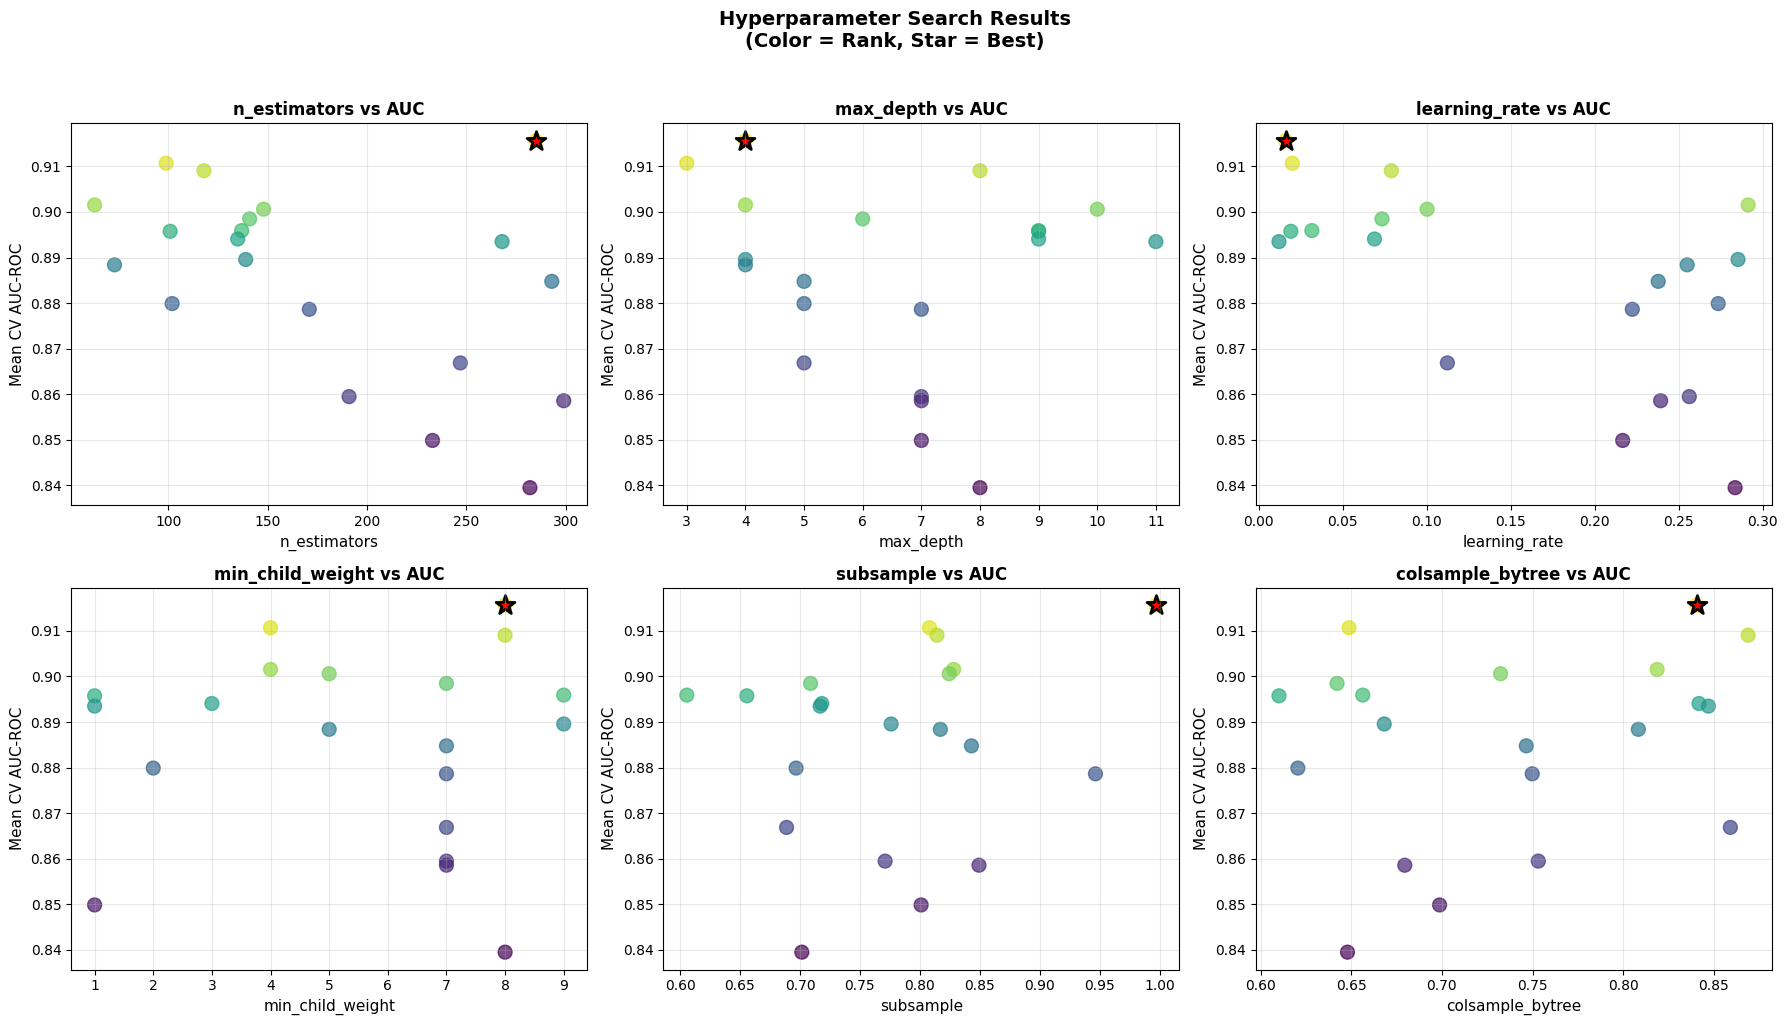

In [19]:
# Visualize Hyperparameter Search Results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Key parameters to visualize
params_to_plot = ['param_n_estimators', 'param_max_depth', 'param_learning_rate', 
                  'param_min_child_weight', 'param_subsample', 'param_colsample_bytree']

for i, param in enumerate(params_to_plot):
    ax = axes[i]
    param_values = cv_results_df[param].astype(float)
    scores = cv_results_df['mean_test_score']
    
    ax.scatter(param_values, scores, c=cv_results_df['rank_test_score'], 
               cmap='viridis_r', s=100, alpha=0.7)
    
    # Highlight best
    best_idx = cv_results_df['rank_test_score'].idxmin()
    ax.scatter(cv_results_df.loc[best_idx, param], cv_results_df.loc[best_idx, 'mean_test_score'],
               c='red', s=200, marker='*', edgecolors='black', linewidths=2, label='Best')
    
    ax.set_xlabel(param.replace('param_', ''), fontsize=11)
    ax.set_ylabel('Mean CV AUC-ROC', fontsize=11)
    ax.set_title(f'{param.replace("param_", "")} vs AUC', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Hyperparameter Search Results\n(Color = Rank, Star = Best)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# Train Final Model with Best Parameters
print("="*60)
print("TRAINING FINAL MODEL WITH BEST PARAMETERS")
print("="*60)

# Use the best estimator from random search
xgb_model_tuned = random_search.best_estimator_

# Or alternatively, create a new model with best params:
# xgb_model_tuned = XGBClassifier(
#     **best_params,
#     scale_pos_weight=scale_pos_weight,
#     random_state=42,
#     eval_metric='auc',
#     use_label_encoder=False,
#     n_jobs=-1
# )
# xgb_model_tuned.fit(X_train_scaled, y_train)

print("✅ Using best estimator from RandomizedSearchCV")
print(f"\nModel Parameters:")
for param, value in best_params.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.4f}")
    else:
        print(f"  {param}: {value}")

TRAINING FINAL MODEL WITH BEST PARAMETERS
✅ Using best estimator from RandomizedSearchCV

Model Parameters:
  colsample_bytree: 0.8404
  gamma: 0.3540
  learning_rate: 0.0160
  max_depth: 4
  min_child_weight: 8
  n_estimators: 285
  reg_alpha: 0.9386
  reg_lambda: 0.5012
  subsample: 0.9969


In [21]:
# Evaluate Tuned Model on Test Set
y_pred_tuned = xgb_model_tuned.predict(X_test_scaled)
y_pred_proba_tuned = xgb_model_tuned.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
auc_score_tuned = roc_auc_score(y_test, y_pred_proba_tuned)
classification_rep_tuned = classification_report(y_test, y_pred_tuned, output_dict=True)

print("\n" + "="*60)
print("TUNED XGBoost MODEL PERFORMANCE (Test Set)")
print("="*60)
print(f"\n   AUC-ROC Score: {auc_score_tuned:.4f}")
print(f"   Accuracy: {classification_rep_tuned['accuracy']:.4f}")
print(f"   Precision (Fraud): {classification_rep_tuned['1']['precision']:.4f}")
print(f"   Recall (Fraud): {classification_rep_tuned['1']['recall']:.4f}")
print(f"   F1-Score (Fraud): {classification_rep_tuned['1']['f1-score']:.4f}")
print(f"   Precision (Legitimate): {classification_rep_tuned['0']['precision']:.4f}")
print(f"   Recall (Legitimate): {classification_rep_tuned['0']['recall']:.4f}")
print(f"   F1-Score (Legitimate): {classification_rep_tuned['0']['f1-score']:.4f}")

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print(f"\n  CONFUSION MATRIX:")
print(f"                 Predicted")
print(f"                 Legit  Fraud")
print(f"Actual Legit     {cm_tuned[0,0]:>5}  {cm_tuned[0,1]:>5}")
print(f"       Fraud     {cm_tuned[1,0]:>5}  {cm_tuned[1,1]:>5}")

# Error rates
tn_t, fp_t, fn_t, tp_t = cm_tuned.ravel()
fpr_tuned = fp_t / (fp_t + tn_t)
fnr_tuned = fn_t / (fn_t + tp_t)

print(f"\n   False Positive Rate: {fpr_tuned:.4f} ({fpr_tuned*100:.2f}%)")
print(f"   False Negative Rate: {fnr_tuned:.4f} ({fnr_tuned*100:.2f}%)")
print(f"   True Positives (Frauds Caught): {tp_t:,}")
print(f"   False Negatives (Frauds Missed): {fn_t:,}")


TUNED XGBoost MODEL PERFORMANCE (Test Set)

   AUC-ROC Score: 0.6809
   Accuracy: 0.8350
   Precision (Fraud): 0.0001
   Recall (Fraud): 0.3396
   F1-Score (Fraud): 0.0002
   Precision (Legitimate): 1.0000
   Recall (Legitimate): 0.8350
   F1-Score (Legitimate): 0.9101

  CONFUSION MATRIX:
                 Predicted
                 Legit  Fraud
Actual Legit     1193914  235915
       Fraud        35     18

   False Positive Rate: 0.1650 (16.50%)
   False Negative Rate: 0.6604 (66.04%)
   True Positives (Frauds Caught): 18
   False Negatives (Frauds Missed): 35


In [22]:
# Compare Default vs Tuned Model
print("="*60)
print("MODEL COMPARISON: Default vs Tuned XGBoost")
print("="*60)

# Default model metrics (from earlier cells - need to run those first)
# If xgb_model exists, compare with it
comparison_data = {
    'Metric': ['AUC-ROC', 'Accuracy', 'Precision (Fraud)', 'Recall (Fraud)', 
               'F1-Score (Fraud)', 'False Positive Rate', 'False Negative Rate'],
    'Tuned Model': [
        auc_score_tuned,
        classification_rep_tuned['accuracy'],
        classification_rep_tuned['1']['precision'],
        classification_rep_tuned['1']['recall'],
        classification_rep_tuned['1']['f1-score'],
        fpr_tuned,
        fnr_tuned
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Format for display
print("\n📊 Tuned Model Performance:")
print("-"*50)
for _, row in comparison_df.iterrows():
    print(f"  {row['Metric']:<25}: {row['Tuned Model']:.4f}")

print("\n💡 Tip: Compare these results with the default XGBoost model below")
print("   to see if hyperparameter tuning improved performance.")

MODEL COMPARISON: Default vs Tuned XGBoost

📊 Tuned Model Performance:
--------------------------------------------------
  AUC-ROC                  : 0.6809
  Accuracy                 : 0.8350
  Precision (Fraud)        : 0.0001
  Recall (Fraud)           : 0.3396
  F1-Score (Fraud)         : 0.0002
  False Positive Rate      : 0.1650
  False Negative Rate      : 0.6604

💡 Tip: Compare these results with the default XGBoost model below
   to see if hyperparameter tuning improved performance.


# XGBoost Model Training

In [23]:
from xgboost import XGBClassifier


# Train XGBoost model
xgb_model = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8404460046972835, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=0.35403628889802274, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01596950334578271,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=8, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=285, n_jobs=-1,
              num_parallel_tree=None, ...)

In [24]:
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [70]:
# Fetch data from ClickHouse for given trans_id(s) and generate score from trained XGBoost model

def fetch_and_score(trans_id_list):
    # Prepare trans_id list for SQL IN clause
    # trans_id_str = ", ".join([f"'{tid}'" for tid in trans_id_list])
    query = f"""
        SELECT *
        from clickhouse.public.stixor_fraud_features_distributed
        WHERE ac_to IN ('6bWJLZ6oeyULlclarEbUZQ==', 'UMGdIiV+NNejufC4KZjQhg==', 'PpSJR/GuPBTgGspVmnZL9Q==', '2cBYlxBr+MonsmXTPa4x9g==','D/RYTgjwnSP3dCE7bNGI1g==')
        AND trx_channel='NEW_JC_APP' AND trx_type='Transfer(C2C)'     
        AND start_balance<>end_balance   
        """
    # Fetch data from ClickHouse
    df_raw = spark.sql(query)
    df = df_raw.toPandas()
    
    # Factorize categorical columns as in training
    for col in features:
        if df[col].dtype == 'object':
            df[col], _ = pd.factorize(df[col])
    
    # Scale features
    X = df[features]
    X_scaled = scaler.transform(X)
    
    # Predict probabilities
    scores = xgb_model.predict_proba(X_scaled)[:, 1]
    df['score'] = scores
    return df

# Example usage:
result_df = fetch_and_score(['84439094747', '84438551204'])
print(result_df)

       trans_id                   ac_from                     ac_to  \
0   83726657056  KPzF4yp5nIzbhSUpDg/51g==  2cBYlxBr+MonsmXTPa4x9g==   
1   83789803564  /BCHSYUiq9dD1vZ0pcZnRw==  6bWJLZ6oeyULlclarEbUZQ==   
2   83418444729  b+Unb8df8HZT/4Ewa+hxeg==  6bWJLZ6oeyULlclarEbUZQ==   
3   83805023019  RXaFvd7tS0tZHODDmp4YWg==  6bWJLZ6oeyULlclarEbUZQ==   
4   83805435970  RXaFvd7tS0tZHODDmp4YWg==  6bWJLZ6oeyULlclarEbUZQ==   
5   83619522019  i8xBFezcRNjH6YmvGg4UjA==  2cBYlxBr+MonsmXTPa4x9g==   
6   83787478410  wL3rIxTdC039VuUtGsjsuQ==  2cBYlxBr+MonsmXTPa4x9g==   
7   83441572336  iD9GrJ57IgmBr24GGn+t8A==  PpSJR/GuPBTgGspVmnZL9Q==   
8   83414692666  kDSlmEf6keXK9374M92AHA==  PpSJR/GuPBTgGspVmnZL9Q==   
9   84451410766  7Q+TFIbpPGCTqZONoyBMlA==  PpSJR/GuPBTgGspVmnZL9Q==   
10  84451978972  7Q+TFIbpPGCTqZONoyBMlA==  PpSJR/GuPBTgGspVmnZL9Q==   
11  84782889713  BmLKnEEM6KzN/mzl86cOXg==  6bWJLZ6oeyULlclarEbUZQ==   
12  83920799816  KaCQ8YLeDisfe2DRV5iw7Q==  PpSJR/GuPBTgGspVmnZL9Q==   
13  83

In [71]:
result_df = result_df.sort_values(by='score', ascending=False)
result_df = result_df[(result_df['score']>0.5)&(result_df['fraud_flag']==0)]

In [75]:
result_df['trans_id'].values

array(['83850287794', '83920799816', '83923275592', '83924421384',
       '83787478410', '83789341172', '83805304374', '83726657056',
       '83853260479', '83853506875', '83805435970', '83805023019',
       '84441482381', '83924108821', '83920988062', '84589822061',
       '83799340365'], dtype=object)

In [25]:
df_test['score'] = y_pred_proba_xgb

In [50]:
df_test[(df_test['fraud_flag'] == 1)&(df_test['score']>0.5)].trans_id.values

array(['83863011837', '83866808539', '83892347802', '83867918073',
       '83880047653', '83880902056', '83852967073', '83849646796',
       '83869625699', '83882842109', '83869049374', '83869154763',
       '83869469552', '83861241695', '83860698564', '83873219916',
       '83874722353', '83881207177'], dtype=object)

In [53]:
df_test[df_test['trans_id']=='84439094747']

,trans_id,cutoff_date,fraud_flag,trx_amt,mbar_registered_channel,hour_of_day,day_of_week,is_weekend,is_night,user_total_txns_3d,...,user_most_used_type_7d,user_last_used_type,user_type_diversity_score_7d,user_avg_amount_per_recipient_7d,user_max_amount_to_single_recipient_7d,user_recipient_concentration_ratio_7d,user_avg_time_between_txns_7d,user_txn_frequency_score_7d,user_days_since_last_txn,score


In [54]:
df_test[(df_test['fraud_flag'] == 0)&(df_test['score']>0.5)].sort_values(by='score', ascending=False).trans_id.values[:100]

array(['83859606813', '83858645248', '83859564749', '83858739438',
       '83865090696', '83866073231', '83860301628', '83862291130',
       '83860837769', '83854053878', '83859710713', '83865032769',
       '83854361792', '83863462659', '83858944876', '83861905947',
       '83853272286', '83855731777', '83858723059', '83857856804',
       '83865372318', '83857026978', '83855256592', '83857499050',
       '83861429147', '83858938397', '83853945897', '83856737673',
       '83856584580', '83862175828', '83863890090', '83855408183',
       '83864195303', '83852743486', '83861656752', '83861181361',
       '83861550943', '83861316368', '83854371884', '83867262758',
       '83861063523', '83858635214', '83866534756', '83866073954',
       '83853941461', '83856092522', '83860085840', '83858724423',
       '83857179641', '83866404659', '83862912015', '83853950823',
       '83862496591', '83865193801', '83856687431', '83855197165',
       '83857551038', '83862959107', '83857825936', '838675664

In [28]:
# Evaluation metrics
auc_score_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
classification_rep_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

print(f"\n{'='*50}")
print(f"   XGBoost Model Performance")
print(f"{'='*50}")
print(f"   AUC-ROC Score: {auc_score_xgb:.4f}")
print(f"   Accuracy: {classification_rep_xgb['accuracy']:.4f}")
print(f"   Precision (Fraud): {classification_rep_xgb['1']['precision']:.4f}")
print(f"   Recall (Fraud): {classification_rep_xgb['1']['recall']:.4f}")
print(f"   F1-Score (Fraud): {classification_rep_xgb['1']['f1-score']:.4f}")
print(f"   Precision (Legitimate): {classification_rep_xgb['0']['precision']:.4f}")
print(f"   Recall (Legitimate): {classification_rep_xgb['0']['recall']:.4f}")
print(f"   F1-Score (Legitimate): {classification_rep_xgb['0']['f1-score']:.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"\n  CONFUSION MATRIX:")
print(f"                 Predicted")
print(f"                 Legit  Fraud")
print(f"Actual Legit     {cm_xgb[0,0]:>5}  {cm_xgb[0,1]:>5}")
print(f"       Fraud     {cm_xgb[1,0]:>5}  {cm_xgb[1,1]:>5}")


   XGBoost Model Performance
   AUC-ROC Score: 0.6809
   Accuracy: 0.8350
   Precision (Fraud): 0.0001
   Recall (Fraud): 0.3396
   F1-Score (Fraud): 0.0002
   Precision (Legitimate): 1.0000
   Recall (Legitimate): 0.8350
   F1-Score (Legitimate): 0.9101

  CONFUSION MATRIX:
                 Predicted
                 Legit  Fraud
Actual Legit     1193914  235915
       Fraud        35     18


In [29]:
# XGBoost Error Rates
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()
fpr_xgb = fp_xgb / (fp_xgb + tn_xgb)
fnr_xgb = fn_xgb / (fn_xgb + tp_xgb)

print(f"   False Positive Rate: {fpr_xgb:.4f} ({fpr_xgb*100:.2f}%)")
print(f"   False Negative Rate: {fnr_xgb:.4f} ({fnr_xgb*100:.2f}%)")
print(f"   True Positives (Frauds Caught): {tp_xgb:,}")
print(f"   False Negatives (Frauds Missed): {fn_xgb:,}")
print(f"   False Positives (Legitimate Flagged): {fp_xgb:,}")

   False Positive Rate: 0.1650 (16.50%)
   False Negative Rate: 0.6604 (66.04%)
   True Positives (Frauds Caught): 18
   False Negatives (Frauds Missed): 35
   False Positives (Legitimate Flagged): 235,915


# Probability Distribution & Calibration Analysis

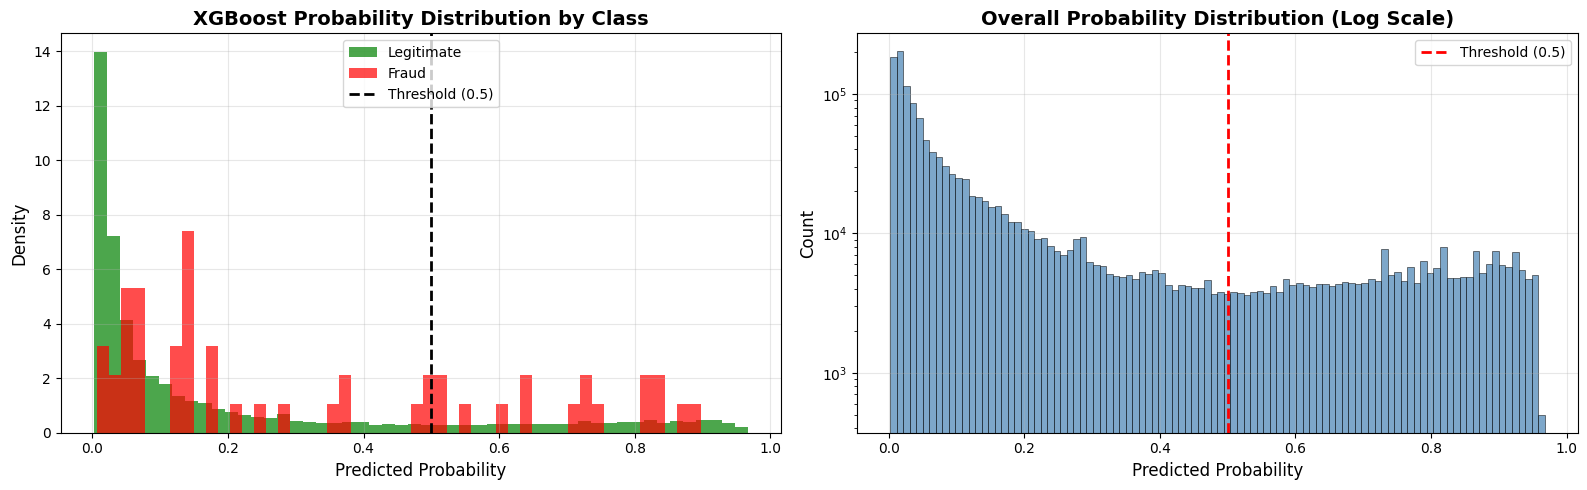


PROBABILITY DISTRIBUTION STATISTICS

Legitimate Transactions (y=0):
  Mean Probability:   0.201839
  Median Probability: 0.063505
  Std Deviation:      0.269764
  Min:                0.001905
  Max:                0.967764

Fraud Transactions (y=1):
  Mean Probability:   0.327410
  Median Probability: 0.176414
  Std Deviation:      0.288058
  Min:                0.007136
  Max:                0.897443


In [30]:
# Probability Distribution Plot - XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution by class
ax1 = axes[0]
ax1.hist(y_pred_proba_xgb[y_test == 0], bins=50, alpha=0.7, label='Legitimate', color='green', density=True)
ax1.hist(y_pred_proba_xgb[y_test == 1], bins=50, alpha=0.7, label='Fraud', color='red', density=True)
ax1.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax1.set_xlabel('Predicted Probability', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('XGBoost Probability Distribution by Class', fontsize=14, fontweight='bold')
ax1.legend(loc='upper center')
ax1.grid(alpha=0.3)

# Overall distribution with log scale
ax2 = axes[1]
ax2.hist(y_pred_proba_xgb, bins=100, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
ax2.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax2.set_xlabel('Predicted Probability', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_yscale('log')
ax2.set_title('Overall Probability Distribution (Log Scale)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*60)
print("PROBABILITY DISTRIBUTION STATISTICS")
print("="*60)
print(f"\nLegitimate Transactions (y=0):")
print(f"  Mean Probability:   {y_pred_proba_xgb[y_test == 0].mean():.6f}")
print(f"  Median Probability: {np.median(y_pred_proba_xgb[y_test == 0]):.6f}")
print(f"  Std Deviation:      {y_pred_proba_xgb[y_test == 0].std():.6f}")
print(f"  Min:                {y_pred_proba_xgb[y_test == 0].min():.6f}")
print(f"  Max:                {y_pred_proba_xgb[y_test == 0].max():.6f}")

print(f"\nFraud Transactions (y=1):")
print(f"  Mean Probability:   {y_pred_proba_xgb[y_test == 1].mean():.6f}")
print(f"  Median Probability: {np.median(y_pred_proba_xgb[y_test == 1]):.6f}")
print(f"  Std Deviation:      {y_pred_proba_xgb[y_test == 1].std():.6f}")
print(f"  Min:                {y_pred_proba_xgb[y_test == 1].min():.6f}")
print(f"  Max:                {y_pred_proba_xgb[y_test == 1].max():.6f}")

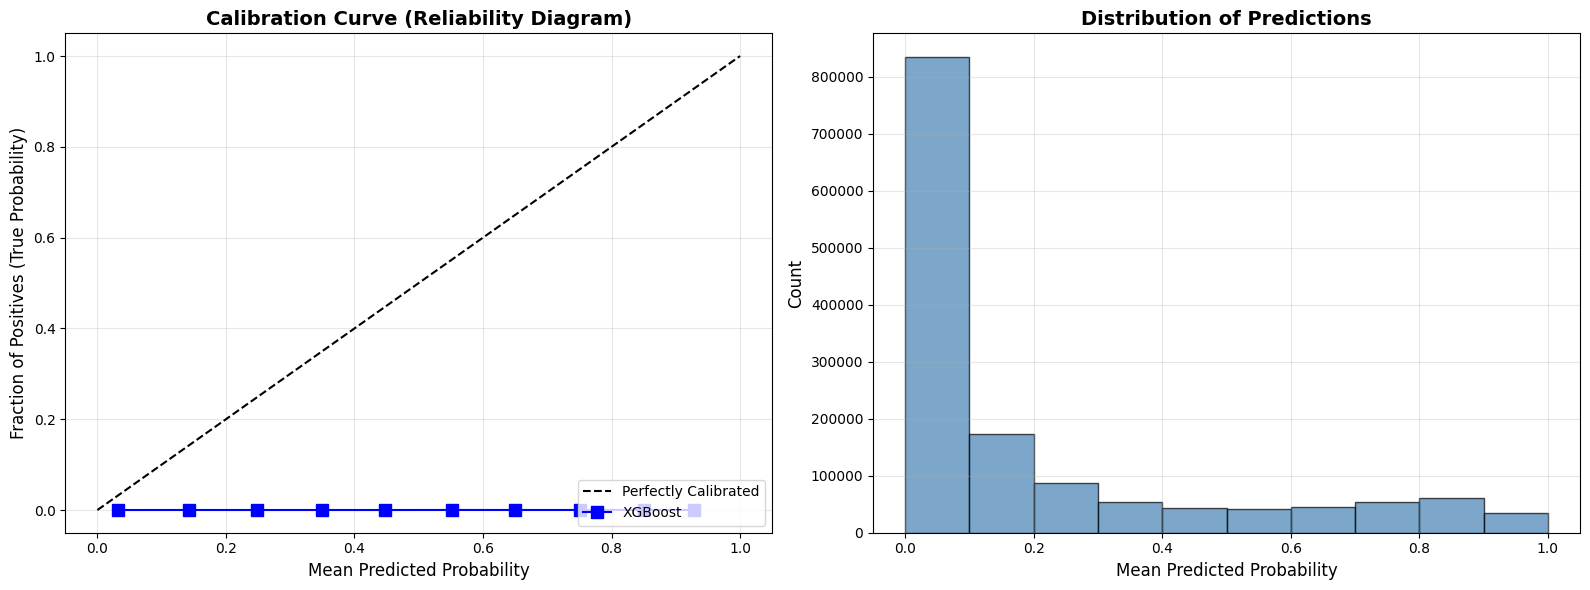


Brier Score (lower is better): 0.113527
  - Brier Score ranges from 0 to 1, where 0 is perfect
  - A well-calibrated model has predictions that match actual probabilities


In [31]:
# Calibration Curve (Reliability Diagram)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calibration curve for XGBoost
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba_xgb, n_bins=10, strategy='uniform')

ax1 = axes[0]
ax1.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
ax1.plot(prob_pred, prob_true, 's-', color='blue', label='XGBoost', markersize=8)
ax1.set_xlabel('Mean Predicted Probability', fontsize=12)
ax1.set_ylabel('Fraction of Positives (True Probability)', fontsize=12)
ax1.set_title('Calibration Curve (Reliability Diagram)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Histogram of predictions per bin
ax2 = axes[1]
ax2.hist(y_pred_proba_xgb, bins=10, range=(0, 1), alpha=0.7, color='steelblue', edgecolor='black')
ax2.set_xlabel('Mean Predicted Probability', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Distribution of Predictions', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Brier Score (calibration metric)
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, y_pred_proba_xgb)
print(f"\nBrier Score (lower is better): {brier:.6f}")
print("  - Brier Score ranges from 0 to 1, where 0 is perfect")
print("  - A well-calibrated model has predictions that match actual probabilities")

In [32]:
# Top Scores Analysis - Precision at Top K
print("="*70)
print("TOP SCORES ANALYSIS - Results at Different Thresholds")
print("="*70)

# Create DataFrame with predictions
results_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred_proba': y_pred_proba_xgb
}).sort_values('y_pred_proba', ascending=False).reset_index(drop=True)

# Analyze top K predictions
top_k_values = [100, 500, 1000, 5000, 10000]

print("\n📊 PRECISION AT TOP K (Highest Risk Transactions)")
print("-"*70)
print(f"{'Top K':>10} | {'Frauds Found':>12} | {'Precision':>10} | {'% of All Frauds':>15}")
print("-"*70)

total_frauds = y_test.sum()

for k in top_k_values:
    if k <= len(results_df):
        top_k_df = results_df.head(k)
        frauds_in_top_k = top_k_df['y_true'].sum()
        precision_at_k = frauds_in_top_k / k
        recall_at_k = frauds_in_top_k / total_frauds * 100
        print(f"{k:>10,} | {frauds_in_top_k:>12,} | {precision_at_k:>10.4f} | {recall_at_k:>14.2f}%")

print("-"*70)
print(f"\nTotal Frauds in Test Set: {total_frauds:,}")
print(f"Total Transactions in Test Set: {len(y_test):,}")

TOP SCORES ANALYSIS - Results at Different Thresholds

📊 PRECISION AT TOP K (Highest Risk Transactions)
----------------------------------------------------------------------
     Top K | Frauds Found |  Precision | % of All Frauds
----------------------------------------------------------------------
       100 |            0 |     0.0000 |           0.00%
       500 |            0 |     0.0000 |           0.00%
     1,000 |            0 |     0.0000 |           0.00%
     5,000 |            0 |     0.0000 |           0.00%
    10,000 |            0 |     0.0000 |           0.00%
----------------------------------------------------------------------

Total Frauds in Test Set: 53
Total Transactions in Test Set: 1,429,882


In [33]:
# Performance at Different Thresholds
print("\n" + "="*70)
print("PERFORMANCE AT DIFFERENT PROBABILITY THRESHOLDS")
print("="*70)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

print(f"\n{'Threshold':>10} | {'Precision':>10} | {'Recall':>10} | {'F1':>10} | {'FPR':>10} | {'Flagged':>12}")
print("-"*75)

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba_xgb >= thresh).astype(int)
    
    tp = ((y_pred_thresh == 1) & (y_test == 1)).sum()
    fp = ((y_pred_thresh == 1) & (y_test == 0)).sum()
    fn = ((y_pred_thresh == 0) & (y_test == 1)).sum()
    tn = ((y_pred_thresh == 0) & (y_test == 0)).sum()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    flagged = (y_pred_thresh == 1).sum()
    
    print(f"{thresh:>10.1f} | {precision:>10.4f} | {recall:>10.4f} | {f1:>10.4f} | {fpr:>10.4f} | {flagged:>12,}")

print("-"*75)


PERFORMANCE AT DIFFERENT PROBABILITY THRESHOLDS

 Threshold |  Precision |     Recall |         F1 |        FPR |      Flagged
---------------------------------------------------------------------------
       0.1 |     0.0001 |     0.7170 |     0.0001 |     0.4164 |      595,413
       0.2 |     0.0001 |     0.4717 |     0.0001 |     0.2947 |      421,437
       0.3 |     0.0001 |     0.4151 |     0.0001 |     0.2331 |      333,354
       0.4 |     0.0001 |     0.3585 |     0.0001 |     0.1952 |      279,150
       0.5 |     0.0001 |     0.3396 |     0.0002 |     0.1650 |      235,933
       0.6 |     0.0001 |     0.2453 |     0.0001 |     0.1364 |      195,085
       0.7 |     0.0001 |     0.1887 |     0.0001 |     0.1051 |      150,345
       0.8 |     0.0001 |     0.1132 |     0.0001 |     0.0671 |       95,928
       0.9 |     0.0000 |     0.0000 |     0.0000 |     0.0243 |       34,691
---------------------------------------------------------------------------


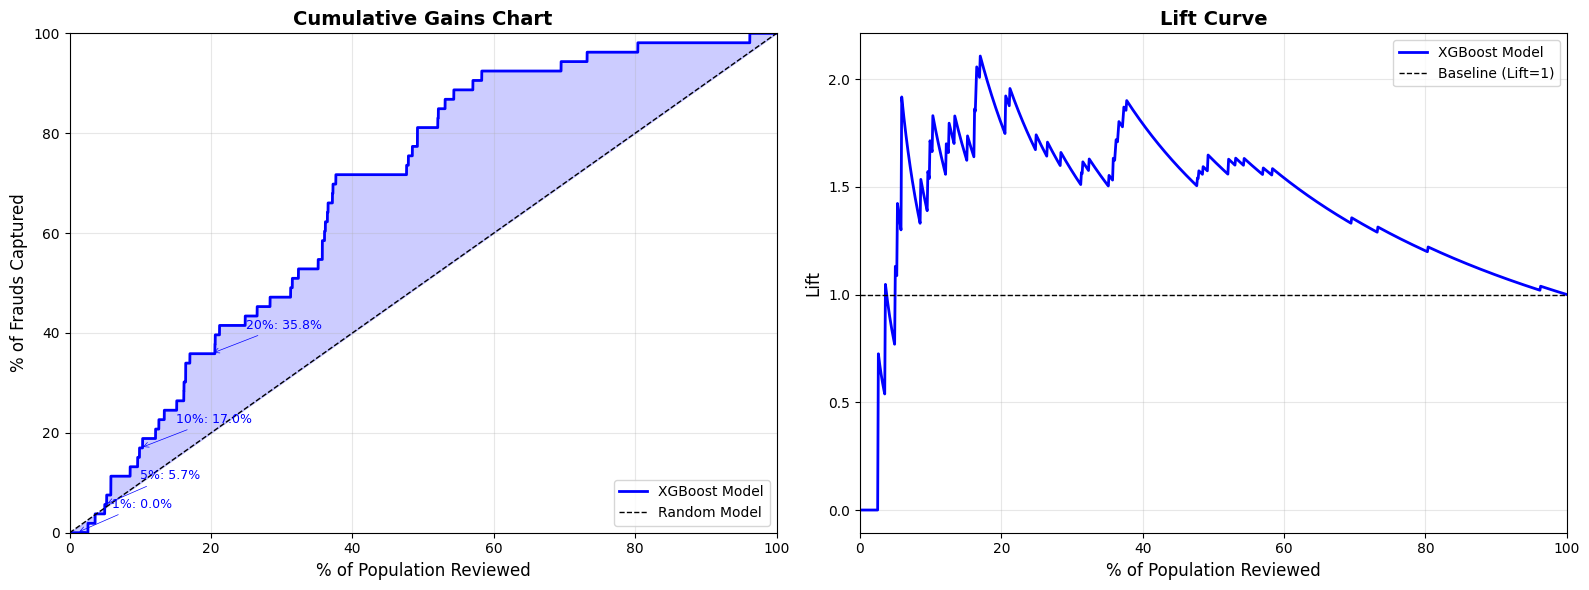


📈 LIFT VALUES AT KEY PERCENTAGES:
--------------------------------------------------
  Top  1% of predictions: Lift = 0.00x
  Top  5% of predictions: Lift = 1.13x
  Top 10% of predictions: Lift = 1.70x
  Top 20% of predictions: Lift = 1.79x
  Top 50% of predictions: Lift = 1.62x
--------------------------------------------------


In [34]:
# Cumulative Gains Chart and Lift Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sort by predicted probability
sorted_indices = np.argsort(y_pred_proba_xgb)[::-1]
y_true_sorted = y_test.values[sorted_indices]

# Calculate cumulative gains
total_frauds = y_true_sorted.sum()
cumulative_frauds = np.cumsum(y_true_sorted)
cumulative_pct = np.arange(1, len(y_true_sorted) + 1) / len(y_true_sorted)
gains = cumulative_frauds / total_frauds

# Cumulative Gains Chart
ax1 = axes[0]
ax1.plot(cumulative_pct * 100, gains * 100, 'b-', linewidth=2, label='XGBoost Model')
ax1.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Random Model')
ax1.fill_between(cumulative_pct * 100, gains * 100, cumulative_pct * 100, alpha=0.2, color='blue')
ax1.set_xlabel('% of Population Reviewed', fontsize=12)
ax1.set_ylabel('% of Frauds Captured', fontsize=12)
ax1.set_title('Cumulative Gains Chart', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)
ax1.set_xlim([0, 100])
ax1.set_ylim([0, 100])

# Add annotations for key percentages
for pct in [1, 5, 10, 20]:
    idx = int(len(y_true_sorted) * pct / 100)
    if idx < len(gains):
        ax1.annotate(f'{pct}%: {gains[idx]*100:.1f}%', 
                    xy=(pct, gains[idx]*100), 
                    xytext=(pct+5, gains[idx]*100+5),
                    fontsize=9, color='blue',
                    arrowprops=dict(arrowstyle='->', color='blue', lw=0.5))

# Lift Curve
ax2 = axes[1]
baseline_rate = total_frauds / len(y_true_sorted)
lift = (cumulative_frauds / np.arange(1, len(y_true_sorted) + 1)) / baseline_rate

# Sample points for cleaner plot
sample_points = np.linspace(0, len(lift)-1, 1000).astype(int)
ax2.plot(cumulative_pct[sample_points] * 100, lift[sample_points], 'b-', linewidth=2, label='XGBoost Model')
ax2.axhline(y=1, color='k', linestyle='--', linewidth=1, label='Baseline (Lift=1)')
ax2.set_xlabel('% of Population Reviewed', fontsize=12)
ax2.set_ylabel('Lift', fontsize=12)
ax2.set_title('Lift Curve', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)
ax2.set_xlim([0, 100])

plt.tight_layout()
plt.show()

# Print key lift values
print("\n📈 LIFT VALUES AT KEY PERCENTAGES:")
print("-"*50)
for pct in [1, 5, 10, 20, 50]:
    idx = int(len(y_true_sorted) * pct / 100)
    if idx < len(lift):
        print(f"  Top {pct:>2}% of predictions: Lift = {lift[idx]:.2f}x")
print("-"*50)

In [35]:
# Top 20 Highest Risk Transactions (Sample)
print("="*80)
print("TOP 20 HIGHEST RISK TRANSACTIONS")
print("="*80)

# Create detailed results with original data
top_scores_df = pd.DataFrame({
    'Rank': range(1, 21),
    'Fraud_Probability': y_pred_proba_xgb[sorted_indices[:20]],
    'Actual_Label': ['FRAUD' if y == 1 else 'LEGIT' for y in y_test.values[sorted_indices[:20]]],
    'Correct': ['✓' if (y_pred_proba_xgb[sorted_indices[i]] >= 0.5) == y_test.values[sorted_indices[i]] else '✗' 
                for i, y in enumerate(y_test.values[sorted_indices[:20]])]
})

print(top_scores_df.to_string(index=False))

# Summary
correct_in_top20 = (top_scores_df['Actual_Label'] == 'FRAUD').sum()
print(f"\n📊 In Top 20: {correct_in_top20} actual frauds ({correct_in_top20/20*100:.0f}% precision)")

TOP 20 HIGHEST RISK TRANSACTIONS
 Rank  Fraud_Probability Actual_Label Correct
    1           0.967764        LEGIT       ✗
    2           0.966870        LEGIT       ✗
    3           0.966870        LEGIT       ✗
    4           0.966870        LEGIT       ✗
    5           0.966683        LEGIT       ✗
    6           0.966490        LEGIT       ✗
    7           0.966103        LEGIT       ✗
    8           0.966103        LEGIT       ✗
    9           0.966103        LEGIT       ✗
   10           0.966103        LEGIT       ✗
   11           0.965771        LEGIT       ✗
   12           0.965771        LEGIT       ✗
   13           0.965771        LEGIT       ✗
   14           0.965771        LEGIT       ✗
   15           0.965771        LEGIT       ✗
   16           0.965771        LEGIT       ✗
   17           0.965771        LEGIT       ✗
   18           0.965771        LEGIT       ✗
   19           0.965771        LEGIT       ✗
   20           0.965771        LEGIT       ✗



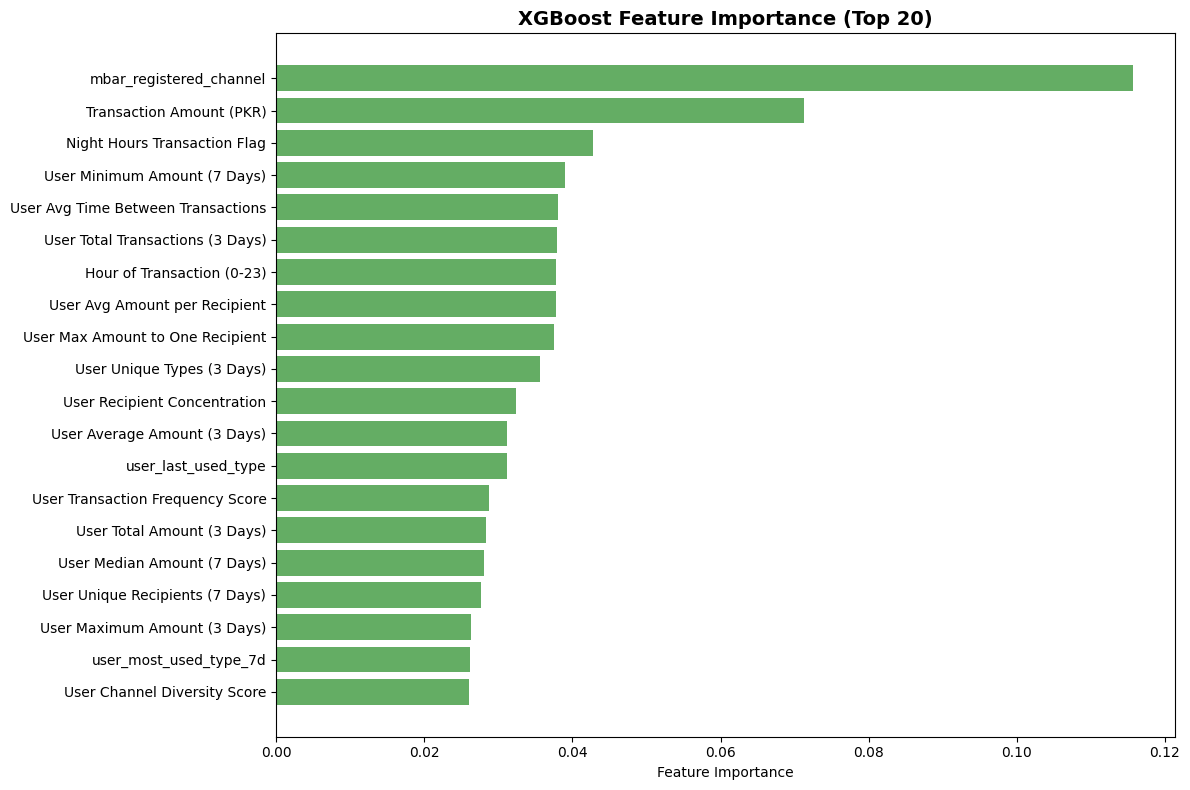


Top 10 Most Important Features:
                               Feature                       Feature_Name  Importance
               mbar_registered_channel            mbar_registered_channel    0.115627
                               trx_amt           Transaction Amount (PKR)    0.071269
                              is_night       Night Hours Transaction Flag    0.042730
                    user_min_amount_7d       User Minimum Amount (7 Days)    0.038969
         user_avg_time_between_txns_7d User Avg Time Between Transactions    0.038095
                    user_total_txns_3d   User Total Transactions (3 Days)    0.037863
                           hour_of_day         Hour of Transaction (0-23)    0.037771
      user_avg_amount_per_recipient_7d      User Avg Amount per Recipient    0.037744
user_max_amount_to_single_recipient_7d   User Max Amount to One Recipient    0.037571
                  user_unique_types_3d         User Unique Types (3 Days)    0.035685


In [36]:
# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': features,
    'Feature_Name': [feature_name_mapping.get(f, f) for f in features],
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_20 = xgb_importance.head(20)
plt.barh(range(len(top_20)), top_20['Importance'].values, color='forestgreen', alpha=0.7)
plt.yticks(range(len(top_20)), [name[:40] for name in top_20['Feature_Name'].values])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance (Top 20)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(xgb_importance.head(10).to_string(index=False))

In [37]:
# XGBoost SHAP Analysis

In [38]:
# Sample for SHAP analysis (XGBoost)
shap_sample_size = min(2000, len(X_test))
X_shap = X_test_scaled[:shap_sample_size]
y_shap = y_test.iloc[:shap_sample_size].values
print(f"Using {shap_sample_size} samples for XGBoost SHAP analysis")

Using 2000 samples for XGBoost SHAP analysis


In [39]:
# Create SHAP Explainer for XGBoost
# Using KernelExplainer as fallback for XGBoost/SHAP compatibility issues

print("Computing SHAP values (this may take a few minutes)...")

# Use a background sample for the explainer
background_sample = shap.sample(X_train_scaled, 100)

# Use KernelExplainer which works with any model
xgb_explainer = shap.KernelExplainer(
    lambda x: xgb_model.predict_proba(x)[:, 1], 
    background_sample
)

# Compute SHAP values (use smaller sample for speed with KernelExplainer)
shap_compute_size = min(500, len(X_shap))
xgb_shap_values = xgb_explainer.shap_values(X_shap[:shap_compute_size], nsamples=100)

# Update X_shap and y_shap to match
X_shap = X_shap[:shap_compute_size]
y_shap = y_shap[:shap_compute_size]

print(f"SHAP values shape: {xgb_shap_values.shape}")

Computing SHAP values (this may take a few minutes)...


  0%|          | 0/500 [00:00<?, ?it/s]

SHAP values shape: (500, 35)


Creating SHAP Feature Importance Plot...


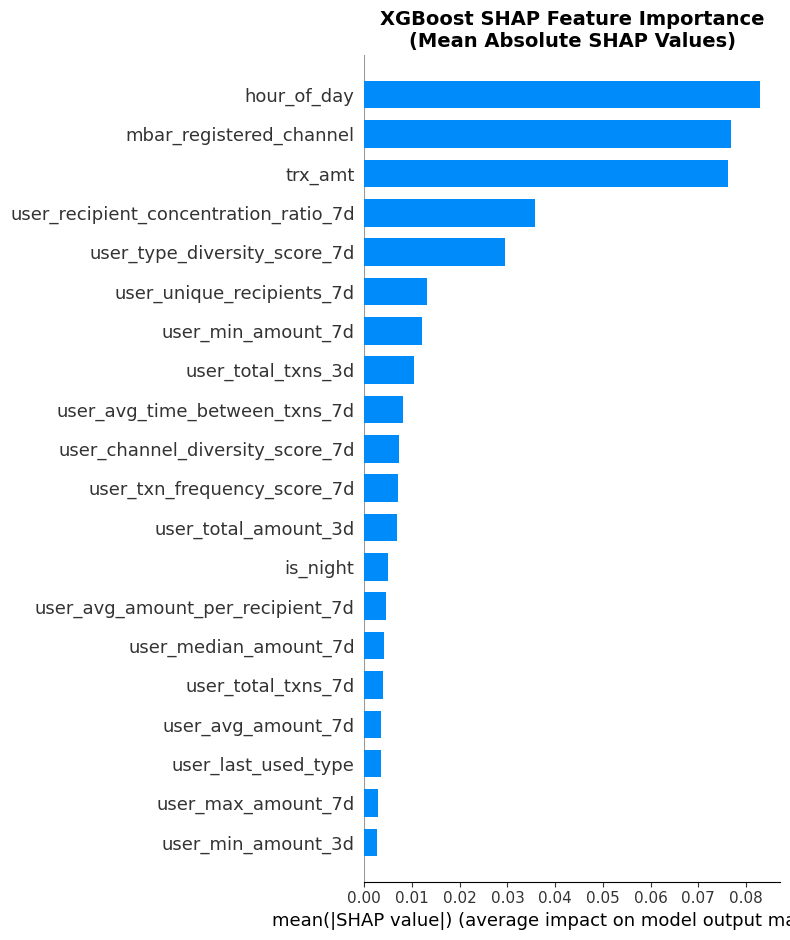

In [40]:
# SHAP Feature Importance Bar Plot
print("Creating SHAP Feature Importance Plot...")
plt.figure(figsize=(12, 10))
shap.summary_plot(xgb_shap_values, X_shap, feature_names=features, 
                  show=False, plot_type="bar")
plt.title('XGBoost SHAP Feature Importance\n(Mean Absolute SHAP Values)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Creating SHAP Summary (Beeswarm) Plot...


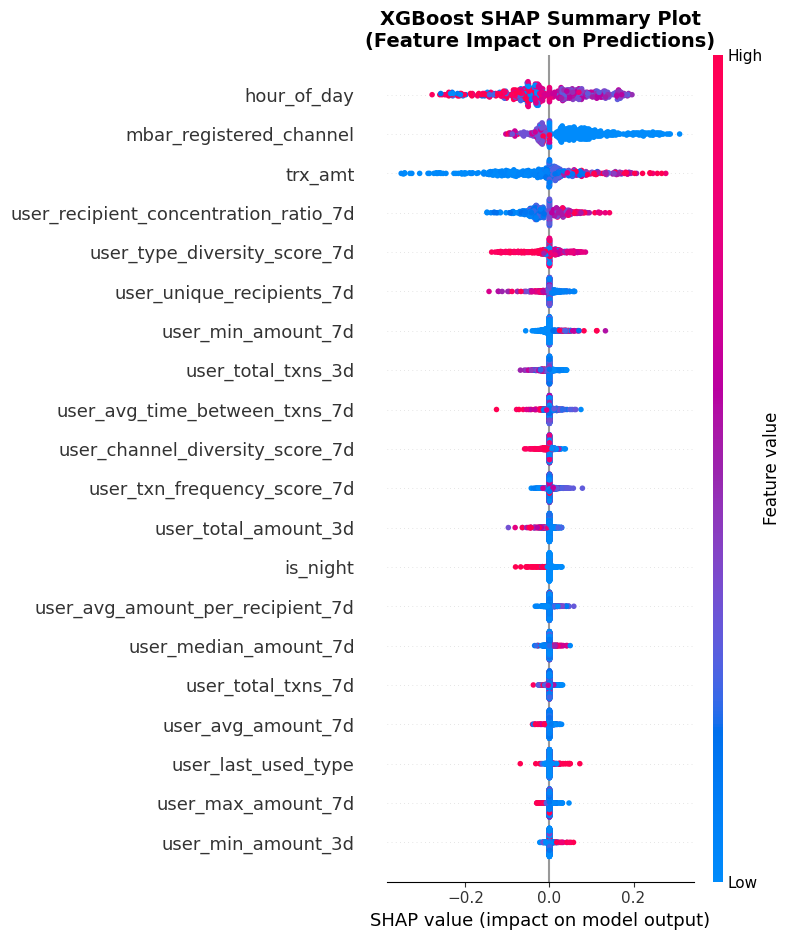

In [41]:
# SHAP Summary Beeswarm Plot
print("Creating SHAP Summary (Beeswarm) Plot...")
plt.figure(figsize=(12, 10))
shap.summary_plot(xgb_shap_values, X_shap, feature_names=features, show=False)
plt.title('XGBoost SHAP Summary Plot\n(Feature Impact on Predictions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

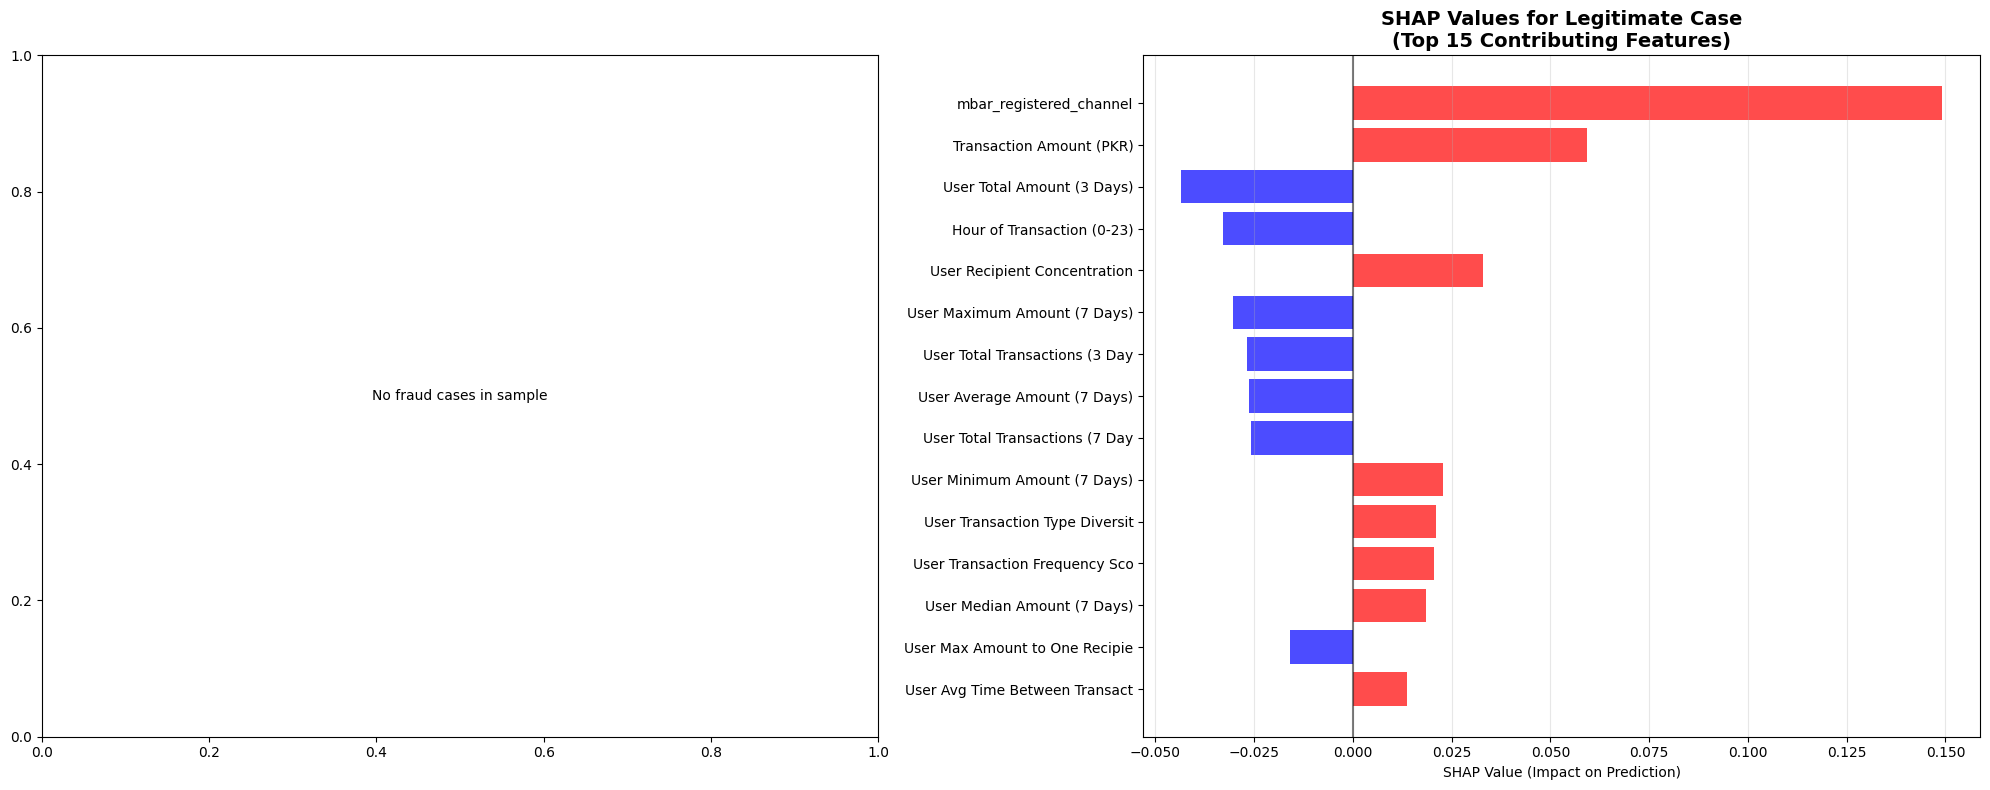

In [42]:
# SHAP Values Comparison: Fraud vs Legitimate Case
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

fraud_indices = np.where(y_shap == 1)[0]
legit_indices = np.where(y_shap == 0)[0]

# Fraud case analysis
if len(fraud_indices) > 0:
    fraud_idx = fraud_indices[0]
    shap_vals = xgb_shap_values[fraud_idx]
    sorted_indices = np.argsort(np.abs(shap_vals))[-15:]
    sorted_shap = shap_vals[sorted_indices]
    sorted_features = [features[i] for i in sorted_indices]
    sorted_names = [feature_name_mapping.get(f, f)[:30] for f in sorted_features]
    
    colors = ['red' if val > 0 else 'blue' for val in sorted_shap]
    ax1.barh(range(len(sorted_shap)), sorted_shap, color=colors, alpha=0.7)
    ax1.set_yticks(range(len(sorted_shap)))
    ax1.set_yticklabels(sorted_names, fontsize=10)
    ax1.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    ax1.set_xlabel('SHAP Value (Impact on Prediction)')
    ax1.set_title('SHAP Values for Fraud Case\n(Top 15 Contributing Features)', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'No fraud cases in sample', ha='center', va='center', transform=ax1.transAxes)

# Legitimate case analysis
if len(legit_indices) > 0:
    legit_idx = legit_indices[0]
    shap_vals = xgb_shap_values[legit_idx]
    sorted_indices = np.argsort(np.abs(shap_vals))[-15:]
    sorted_shap = shap_vals[sorted_indices]
    sorted_features = [features[i] for i in sorted_indices]
    sorted_names = [feature_name_mapping.get(f, f)[:30] for f in sorted_features]
    
    colors = ['red' if val > 0 else 'blue' for val in sorted_shap]
    ax2.barh(range(len(sorted_shap)), sorted_shap, color=colors, alpha=0.7)
    ax2.set_yticks(range(len(sorted_shap)))
    ax2.set_yticklabels(sorted_names, fontsize=10)
    ax2.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    ax2.set_xlabel('SHAP Value (Impact on Prediction)')
    ax2.set_title('SHAP Values for Legitimate Case\n(Top 15 Contributing Features)', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No legitimate cases in sample', ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

In [43]:
# Compute Mean Absolute SHAP Values per Feature
shap_importance_df = pd.DataFrame({
    'Feature': features,
    'Feature_Name': [feature_name_mapping.get(f, f) for f in features],
    'Mean_Abs_SHAP': np.abs(xgb_shap_values).mean(axis=0),
    'Mean_SHAP': xgb_shap_values.mean(axis=0),
    'Std_SHAP': xgb_shap_values.std(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("Top 20 Features by Mean |SHAP| Value:")
print(shap_importance_df.head(20).to_string(index=False))

Top 20 Features by Mean |SHAP| Value:
                              Feature                       Feature_Name  Mean_Abs_SHAP  Mean_SHAP  Std_SHAP
                          hour_of_day         Hour of Transaction (0-23)       0.082975  -0.006700  0.102017
              mbar_registered_channel            mbar_registered_channel       0.076787   0.059049  0.083632
                              trx_amt           Transaction Amount (PKR)       0.076224  -0.014948  0.104754
user_recipient_concentration_ratio_7d       User Recipient Concentration       0.035727  -0.006808  0.044295
         user_type_diversity_score_7d    User Transaction Type Diversity       0.029443  -0.008172  0.041517
            user_unique_recipients_7d    User Unique Recipients (7 Days)       0.013160  -0.001081  0.022659
                   user_min_amount_7d       User Minimum Amount (7 Days)       0.012099   0.003175  0.020472
                   user_total_txns_3d   User Total Transactions (3 Days)       0.010443  -

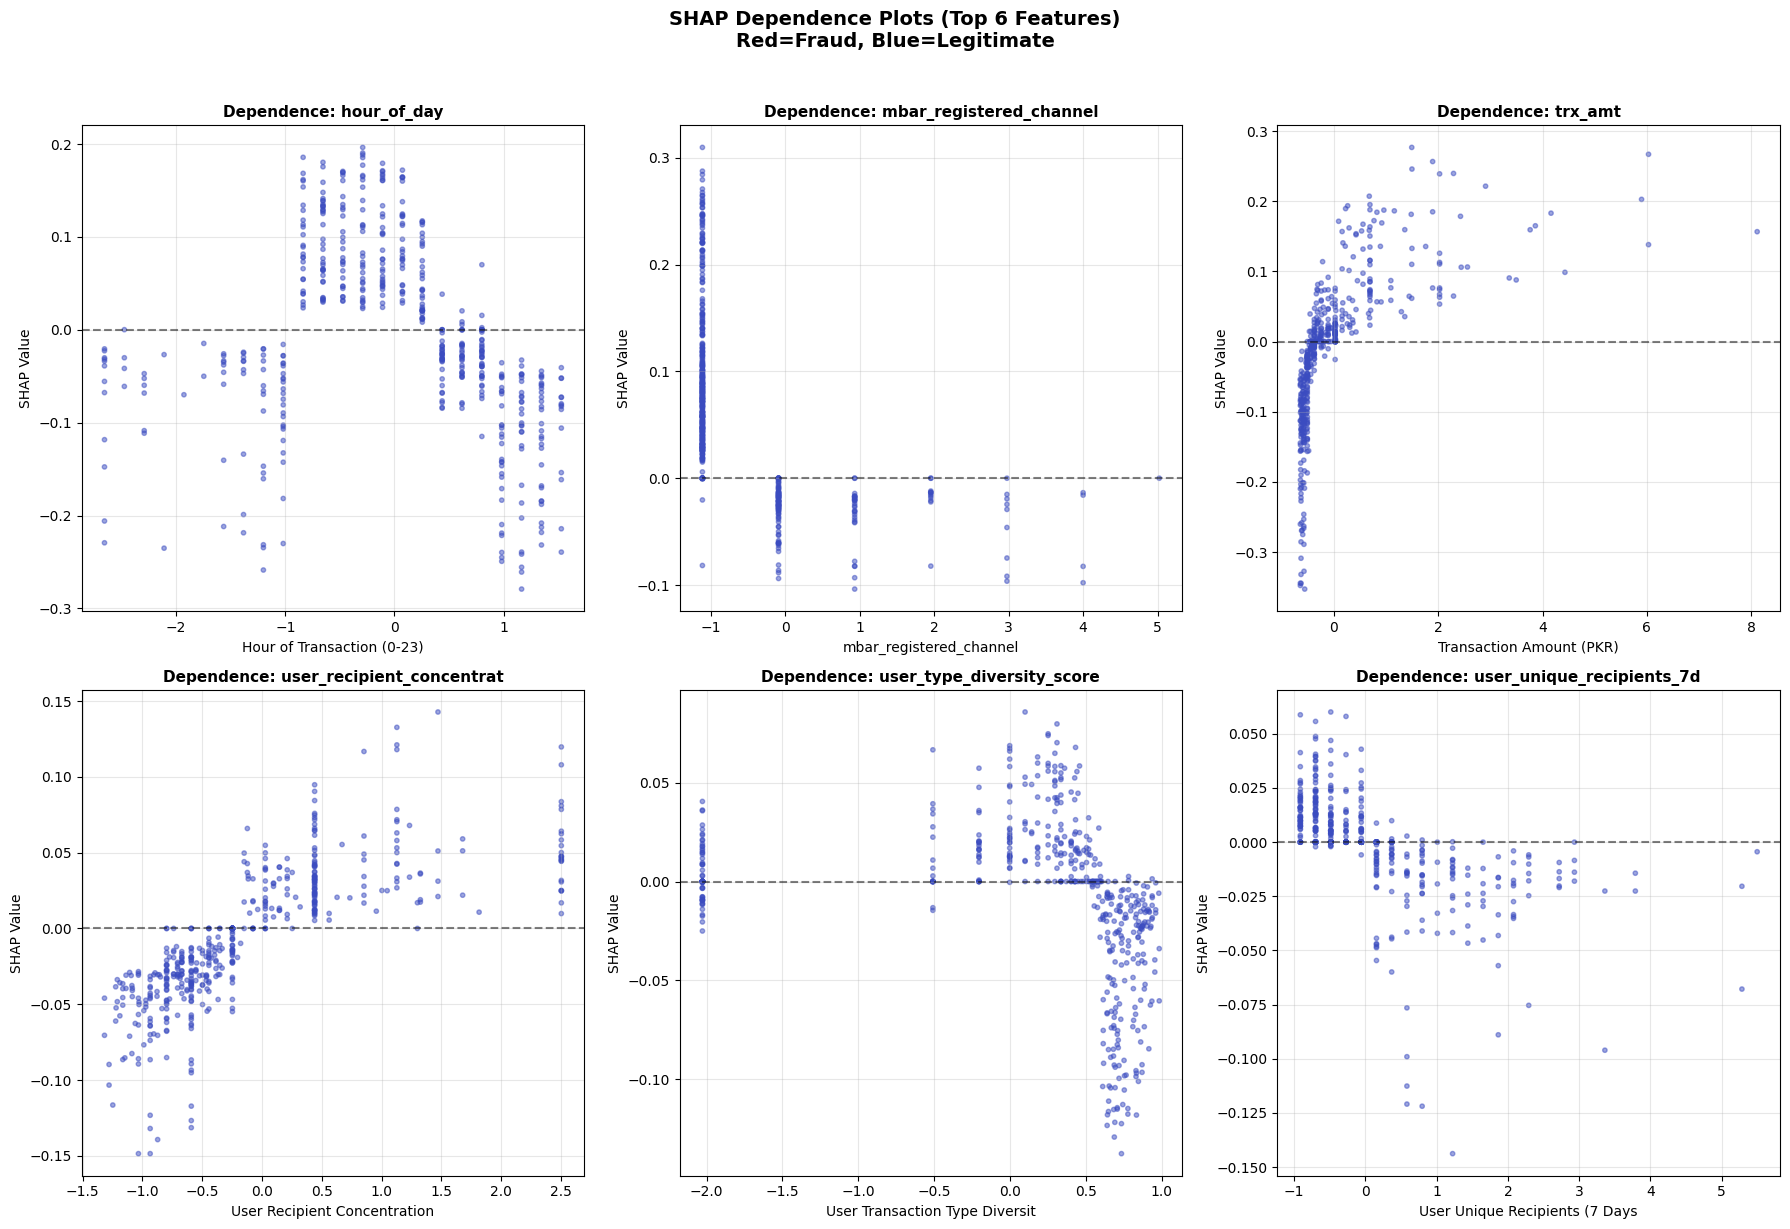

In [44]:
# SHAP Dependence Plots for Top 6 Features
top_6_features = shap_importance_df.head(6)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(top_6_features):
    feature_idx = features.index(feature)
    ax = axes[i]
    
    feature_values = X_shap[:, feature_idx]
    feature_shap = xgb_shap_values[:, feature_idx]
    
    scatter = ax.scatter(feature_values, feature_shap, 
                        c=y_shap, cmap='coolwarm', alpha=0.5, s=10)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel(feature_name_mapping.get(feature, feature)[:30], fontsize=10)
    ax.set_ylabel('SHAP Value', fontsize=10)
    ax.set_title(f'Dependence: {feature[:25]}', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('SHAP Dependence Plots (Top 6 Features)\nRed=Fraud, Blue=Legitimate', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [45]:
# SHAP Waterfall Plot for a Fraud Case
if len(fraud_indices) > 0:
    fraud_idx = fraud_indices[0]
    
    # Get expected value (base value)
    if hasattr(xgb_explainer, 'expected_value'):
        base_value = xgb_explainer.expected_value
        if isinstance(base_value, np.ndarray):
            base_value = base_value[0] if len(base_value) == 1 else base_value.mean()
    else:
        # Fallback: use mean prediction
        base_value = xgb_model.predict_proba(X_train_scaled[:1000])[:, 1].mean()
    
    # Create SHAP Explanation object
    shap_explanation = shap.Explanation(
        values=xgb_shap_values[fraud_idx],
        base_values=base_value,
        data=X_shap[fraud_idx],
        feature_names=features
    )
    
    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(shap_explanation, max_display=15, show=False)
    plt.title('SHAP Waterfall Plot - Fraud Case Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No fraud cases available for waterfall plot")

No fraud cases available for waterfall plot


In [46]:
# Save Scaler, Model, Best Params, Eval Metrics, and Prediction Scores
import joblib
import json
import os
from datetime import datetime

# Create output directory
output_dir = "model_artifacts"
os.makedirs(output_dir, exist_ok=True)

# Date prefix for file naming
date_prefix = datetime.now().strftime("%Y%m%d")
model_prefix = f"xgb_c2c_{date_prefix}"

print("="*60)
print("SAVING MODEL ARTIFACTS")
print("="*60)

# 1. Save the StandardScaler
scaler_path = os.path.join(output_dir, f"{model_prefix}_scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler saved: {scaler_path}")

# 2. Save the XGBoost model
model_path = os.path.join(output_dir, f"{model_prefix}_model.pkl")
joblib.dump(xgb_model, model_path)
print(f"✅ Model saved: {model_path}")

# 3. Save best hyperparameters
best_params_path = os.path.join(output_dir, f"{model_prefix}_best_params.json")
# Convert numpy types to Python types for JSON serialization
best_params_serializable = {k: int(v) if isinstance(v, (np.integer, np.int64)) else 
                            float(v) if isinstance(v, (np.floating, np.float64)) else v 
                            for k, v in best_params.items()}
with open(best_params_path, 'w') as f:
    json.dump(best_params_serializable, f, indent=4)
print(f"✅ Best params saved: {best_params_path}")

# 4. Save evaluation metrics
eval_metrics = {
    'model_name': model_prefix,
    'train_date_range': f"{TRAIN_START_DATE} to {TRAIN_END_DATE}",
    'test_date_range': f"{TEST_START_DATE} to {TEST_END_DATE}",
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'scale_pos_weight': float(scale_pos_weight),
    'auc_roc': float(auc_score_xgb),
    'accuracy': float(classification_rep_xgb['accuracy']),
    'precision_fraud': float(classification_rep_xgb['1']['precision']),
    'recall_fraud': float(classification_rep_xgb['1']['recall']),
    'f1_fraud': float(classification_rep_xgb['1']['f1-score']),
    'precision_legit': float(classification_rep_xgb['0']['precision']),
    'recall_legit': float(classification_rep_xgb['0']['recall']),
    'f1_legit': float(classification_rep_xgb['0']['f1-score']),
    'false_positive_rate': float(fpr_xgb),
    'false_negative_rate': float(fnr_xgb),
    'true_positives': int(tp_xgb),
    'false_positives': int(fp_xgb),
    'true_negatives': int(tn_xgb),
    'false_negatives': int(fn_xgb),
    'confusion_matrix': cm_xgb.tolist(),
    'best_cv_auc_score': float(random_search.best_score_),
    'features': features,
    'best_params': best_params_serializable
}

metrics_path = os.path.join(output_dir, f"{model_prefix}_eval_metrics.json")
with open(metrics_path, 'w') as f:
    json.dump(eval_metrics, f, indent=4)
print(f"✅ Eval metrics saved: {metrics_path}")

# 5. Save prediction scores with test data
predictions_df = df_test.copy()
predictions_df['predicted_probability'] = y_pred_proba_xgb
predictions_df['predicted_label'] = y_pred_xgb
predictions_df['model_name'] = model_prefix
predictions_df['prediction_date'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

predictions_path = os.path.join(output_dir, f"{model_prefix}_predictions.csv")
predictions_df.to_csv(predictions_path, index=False)
print(f"✅ Predictions saved: {predictions_path}")

print("\n" + "="*60)
print("ALL ARTIFACTS SAVED SUCCESSFULLY")
print("="*60)
print(f"\nOutput directory: {os.path.abspath(output_dir)}")
print(f"\nFiles saved:")
print(f"  1. {model_prefix}_scaler.pkl")
print(f"  2. {model_prefix}_model.pkl")
print(f"  3. {model_prefix}_best_params.json")
print(f"  4. {model_prefix}_eval_metrics.json")
print(f"  5. {model_prefix}_predictions.csv")

SAVING MODEL ARTIFACTS
✅ Scaler saved: model_artifacts/xgb_c2c_20251222_scaler.pkl
✅ Model saved: model_artifacts/xgb_c2c_20251222_model.pkl
✅ Best params saved: model_artifacts/xgb_c2c_20251222_best_params.json
✅ Eval metrics saved: model_artifacts/xgb_c2c_20251222_eval_metrics.json
✅ Predictions saved: model_artifacts/xgb_c2c_20251222_predictions.csv

ALL ARTIFACTS SAVED SUCCESSFULLY

Output directory: /root/research-dir/dev/jazzcash-fraud-detection/scripts/training/model_artifacts

Files saved:
  1. xgb_c2c_20251222_scaler.pkl
  2. xgb_c2c_20251222_model.pkl
  3. xgb_c2c_20251222_best_params.json
  4. xgb_c2c_20251222_eval_metrics.json
  5. xgb_c2c_20251222_predictions.csv
✅ Predictions saved: model_artifacts/xgb_c2c_20251222_predictions.csv

ALL ARTIFACTS SAVED SUCCESSFULLY

Output directory: /root/research-dir/dev/jazzcash-fraud-detection/scripts/training/model_artifacts

Files saved:
  1. xgb_c2c_20251222_scaler.pkl
  2. xgb_c2c_20251222_model.pkl
  3. xgb_c2c_20251222_best_param